## ZCB Bond Yield Curve

### Miniproject 2 | Valuation for Financial Engineering.

Team:
- Jiayi Chen
- Esteban López Araiza Bravo

### Assumptions  
We will make the rates continuous for easy calculations.




In [1]:
# Libraries
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path
from datetime import datetime

# Change working directory to the project root
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)
    
PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

print("PROJECT ROOT:", PROJECT_ROOT)

PROJECT ROOT: c:\Users\samla\zcb_treasury_curve


Next, check the raw data

In [2]:
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'

bond_data = pd.read_excel(RAW_ROOT / 'Treasury curve 090426.xlsx')

bond_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Maturity     353 non-null    datetime64[ns]
 1   Coupon       353 non-null    float64       
 2   Bid          353 non-null    float64       
 3   Asked        353 non-null    float64       
 4   Chg          353 non-null    object        
 5   Asked yield  353 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 16.7+ KB


In [3]:
bond_data.head(10)

,Maturity,Coupon,Bid,Asked,Chg,Asked yield
0,2026-09-15,4.625,100.000,100.010,-0.002,2.937
1,2026-09-30,0.875,99.256,99.266,0.01,3.625
2,2026-09-30,1.625,99.276,99.286,0.004,3.318
3,2026-09-30,3.500,99.306,99.316,0.002,3.603
4,2026-10-15,4.625,100.022,100.032,-0.002,3.576
5,2026-10-31,1.125,99.186,99.196,0.01,3.808
6,2026-10-31,1.625,99.212,99.222,0.008,3.755
7,2026-10-31,4.125,100.000,100.010,-0.006,3.877
8,2026-11-15,2.000,99.204,99.214,0.004,3.787
9,2026-11-15,4.625,100.040,100.050,-0.002,3.741


As we can see, the ``Chg`` column should be float64 too, this means there are some values that are not numbers, must be ``NULL``.

In [4]:
bad = bond_data[~bond_data['Chg'].map(pd.api.types.is_float)]
print(bad)

      Maturity  Coupon      Bid    Asked    Chg  Asked yield
18  2027-01-15   4.000  100.010  100.020  unch.        3.807
26  2027-02-28   4.125  100.016  100.026  unch.        3.940
31  2027-04-15   4.500  100.082  100.092  unch.        4.002
33  2027-04-30   2.750   99.044   99.054  unch.        4.061
42  2027-06-30   3.250   99.092   99.102  unch.        4.107
59  2027-10-31   0.500   95.260   95.270  unch.        4.260
263 2040-08-15   1.125   60.274   60.294  unch.        5.069
273 2041-11-15   3.125   79.044   79.064  unch.        5.110
280 2042-08-15   3.375   80.224   80.244  unch.        5.160
281 2042-11-15   2.750   73.144   73.164  unch.        5.188
286 2043-05-15   3.875   85.116   85.136  unch.        5.190
330 2051-02-15   1.875   52.294   52.314  unch.        5.343
336 2052-08-15   3.000   67.190   67.210  unch.        5.311
340 2053-08-15   4.125   83.120   83.140  unch.        5.285
347 2055-05-15   4.750   92.136   92.156  unch.        5.259
352 2056-08-15   5.125  

The non float values seem to be "unch" wich means unchanged, so they can be changed to 0.

In [5]:
bond_data.loc[:, 'Chg'] = bond_data.loc[:, 'Chg'].replace('unch.', 0.0).astype(float)

C:\Users\samla\AppData\Local\Temp\ipykernel_135120\522726813.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bond_data.loc[:, 'Chg'] = bond_data.loc[:, 'Chg'].replace('unch.', 0.0).astype(float)


## Dirty prices

### Assumptions

- We also know that the asked price is the clean price, but for this project we need dirty prices, this means clean prices + accrued interest. We will first get the accrued interest and then create a new column for the Dirty Price.   
- We also know that the bonds and notes in the excel file pay coupons every six months.  
- As the data is of 09/04/2026, the curve, the accrued days and the dirty price should all be at the same date
- The decimals for bid and Asked price are in Treasury form (the first two should be divided by 32 and after that divided by 256). See [IRS's Valuation of Government Securities](https://www.irs.gov/pub/irs-tege/teb2a03.pdf) and [FAQs about Security BuyBacks](https://treasurydirect.gov/help-center/faqs/buyback-faqs/)
- We will use the ``asked`` column as the clean price before changing to decimal instead of Treasury form
- The principal is 100

In [6]:
# import utils
from src.utils import treasury_form_2_decimal

valuation_date = datetime(2026, 9, 4)  # September 4, 2026

bond_data['Clean Price'] = bond_data['Asked'].apply(treasury_form_2_decimal)
bond_data.head(10)

,Maturity,Coupon,Bid,Asked,Chg,Asked yield,Clean Price
0,2026-09-15,4.625,100.000,100.010,-0.002,2.937,100.031250
1,2026-09-30,0.875,99.256,99.266,0.01,3.625,99.835938
2,2026-09-30,1.625,99.276,99.286,0.004,3.318,99.898438
3,2026-09-30,3.500,99.306,99.316,0.002,3.603,99.992188
4,2026-10-15,4.625,100.022,100.032,-0.002,3.576,100.097656
5,2026-10-31,1.125,99.186,99.196,0.01,3.808,99.613281
6,2026-10-31,1.625,99.212,99.222,0.008,3.755,99.691406
7,2026-10-31,4.125,100.000,100.010,-0.006,3.877,100.031250
8,2026-11-15,2.000,99.204,99.214,0.004,3.787,99.667969
9,2026-11-15,4.625,100.040,100.050,-0.002,3.741,100.160156


In [7]:
# sanity check 
clean_price1 = bond_data.loc[0, 'Clean Price']
manual1 = 100 + 1 / 32 + 0 / 256

clean_price2 = bond_data.loc[1, 'Clean Price']
manual2 = 99 + 26 / 32 + 6 / 256
print('Sanity Check:')
print(f"Function Clean Price 1: {clean_price1}, Manual Clean Price 1: {manual1}")
print(f"Function Clean Price 2: {clean_price2}, Manual Clean Price 2: {manual2}")

Sanity Check:
Function Clean Price 1: 100.03125, Manual Clean Price 1: 100.03125
Function Clean Price 2: 99.8359375, Manual Clean Price 2: 99.8359375


In [8]:
# Get Days to Maturity
bond_data['DTM'] = (pd.to_datetime(bond_data['Maturity'], format='%m/%d/%y') - valuation_date).dt.days
bond_data.head(10)

,Maturity,Coupon,Bid,Asked,Chg,Asked yield,Clean Price,DTM
0,2026-09-15,4.625,100.000,100.010,-0.002,2.937,100.031250,11
1,2026-09-30,0.875,99.256,99.266,0.01,3.625,99.835938,26
2,2026-09-30,1.625,99.276,99.286,0.004,3.318,99.898438,26
3,2026-09-30,3.500,99.306,99.316,0.002,3.603,99.992188,26
4,2026-10-15,4.625,100.022,100.032,-0.002,3.576,100.097656,41
5,2026-10-31,1.125,99.186,99.196,0.01,3.808,99.613281,57
6,2026-10-31,1.625,99.212,99.222,0.008,3.755,99.691406,57
7,2026-10-31,4.125,100.000,100.010,-0.006,3.877,100.031250,57
8,2026-11-15,2.000,99.204,99.214,0.004,3.787,99.667969,72
9,2026-11-15,4.625,100.040,100.050,-0.002,3.741,100.160156,72


As we can see, we have multiple bonds with the same maturity, there are two ways we can decide which ones to use. We could use only the ones which asked yield is closer to the coupon rate for normal bootstrapping or we can use all bonds with the Svensson model. 

### Accrual days and interest
As treasury notes and bonds use Actual/Actual for cashflows, this means each accrual day should reflect the actual days, i.e. 180, 181, 182.  
For the accrual interest we will first get the weighted accrual days for the actual number of days in the coupon an then multiply it by the coupon rate divided by two, considering its a semiannual rate.


In [9]:
from src.bond_funs import current_coupon_dates
bond_data[["Accrual Start", "Accrual End"]] = bond_data.apply(
    lambda row: current_coupon_dates(
        row["Maturity"],
        valuation_date,
    ),
    axis=1,
)
bond_data["Accrued Days"] = (
    valuation_date - bond_data["Accrual Start"]
).dt.days

bond_data["Coupon Period Days"] = (
    bond_data["Accrual End"] - bond_data["Accrual Start"]
).dt.days

bond_data["Accrued Fraction"] = (
    bond_data["Accrued Days"] / bond_data["Coupon Period Days"]
)
bond_data["Accrued Interest"] = (
    bond_data["Coupon"] / 2
    * bond_data["Accrued Fraction"]
)

bond_data[["Accrual Start", "Accrual End", "Accrued Days", "Coupon Period Days", "Accrued Fraction", "Accrued Interest"]].head(10)

,Accrual Start,Accrual End,Accrued Days,Coupon Period Days,Accrued Fraction,Accrued Interest
0,2026-03-15,2026-09-15,173,184,0.940217,2.174253
1,2026-03-31,2026-09-30,157,183,0.857923,0.375342
2,2026-03-31,2026-09-30,157,183,0.857923,0.697063
3,2026-03-31,2026-09-30,157,183,0.857923,1.501366
4,2026-04-15,2026-10-15,142,183,0.775956,1.794399
5,2026-04-30,2026-10-31,127,184,0.690217,0.388247
6,2026-04-30,2026-10-31,127,184,0.690217,0.560802
7,2026-04-30,2026-10-31,127,184,0.690217,1.423573
8,2026-05-15,2026-11-15,112,184,0.608696,0.608696
9,2026-05-15,2026-11-15,112,184,0.608696,1.407609


### Dirty Price

Clean price + accrued interest


In [10]:
bond_data['Dirty Price'] = bond_data['Clean Price'] + bond_data['Accrued Interest']

bond_data[['Clean Price', 'Accrued Interest', 'Dirty Price']].head(10)

,Clean Price,Accrued Interest,Dirty Price
0,100.031250,2.174253,102.205503
1,99.835938,0.375342,100.211279
2,99.898438,0.697063,100.595500
3,99.992188,1.501366,101.493554
4,100.097656,1.794399,101.892055
5,99.613281,0.388247,100.001529
6,99.691406,0.560802,100.252208
7,100.031250,1.423573,101.454823
8,99.667969,0.608696,100.276664
9,100.160156,1.407609,101.567765


In [11]:
# Save data
bond_data.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'bond_data.csv', index=False)    

## Curve building model
For this project we decided to use the Svensson model as it is the one that most central banks use. This is the model we will use:

$$DF(t) = e^{-z(t)t}$$

where:
- $z(t)$ is the spot zero continuous rate
- $DF(t)$ is the discount factor
- $t$ is the time in years since the valuation date

Then, the theoretical dirty price for any given bond is:  
$$
Dirty^{model}_i = \sum^{N_i}_{j=1}{CF_{ij}e^{-z(t_{ij})t_{ij}}}
$$
Where the last cashflow includes the principal and the coupon
$$ CF_{i,N} = 100 + \frac{Coupon_i}{2} $$

and:
- $i$ is the bond index, with $i \in \{ 1, 2, \ldots, N \}$
- $CF_{i,j}$ is the cash flow $j$ for the bond $i$
- $N_i$ is the number of the remaining cashflows for bond $i$
- $Coupon_i$ is the annual coupon amount per $100 of principal.

The formula for $z(t_{ij})$ using Svensson model is:

$$
\begin{aligned}
z(t_{i,j})
={}&
\beta_0
+
\beta_1
\left(
\frac{1-e^{-t_{i,j}/\tau_1}}
{t_{i,j}/\tau_1}
\right)
\\[4pt]
&+
\beta_2
\left(
\frac{1-e^{-t_{i,j}/\tau_1}}
{t_{i,j}/\tau_1}
-
e^{-t_{i,j}/\tau_1}
\right)
\\[4pt]
&+
\beta_3
\left(
\frac{1-e^{-t_{i,j}/\tau_2}}
{t_{i,j}/\tau_2}
-
e^{-t_{i,j}/\tau_2}
\right)
\end{aligned}
$$

The model has six parameters:

$$
\theta=
(\beta_0,\beta_1,\beta_2,\beta_3,\tau_1,\tau_2)
$$

where:
- $\beta_0$ is the long-term rate
- $\beta_1$ is the short-term slope 
- $\beta_2$ is the first curvature
- $\beta_3$ is the second curvature
- $\tau_1$ determines when will $\beta_2$ will appear in years
- $\tau_2$ determines when will $\beta_3$ will appear in years

These parameters are common to all bonds and are estimated by minimizing the difference between observed and model-implied dirty prices:
$$
\widehat{\theta}
=
\underset{\theta}{\operatorname{arg\,min}}
\sum_{i=1}^{N}
\left(
Dirty_i^{observed}
-
Dirty_i^{model}(\theta)
\right)^2
$$

### Next Steps
- Make Dirty Price Function
- Make Svensson zero rate function
- Make residual function
- Sanity check for a single bond
- Perform minimizer using least squares 

Estimate Initial Values of β0 and β1 from finding mean of short-term and long-term bonds

In [12]:
# Derive initial parameters from bond_data
from src.bond_funs import coupon_schedule

# 1. β0 (long-term rate): Use average yield from all bonds
mean_yield = bond_data['Asked yield'].mean() / 100
print(f"Mean yield: {mean_yield:.6f}")

# 2. Separate short-term and long-term bonds
short_term = bond_data[bond_data['DTM'] < 365]  # < 1 year
long_term = bond_data[bond_data['DTM'] > 3650]   # > 10 years

if len(short_term) > 0 and len(long_term) > 0:
    short_yield = short_term['Asked yield'].mean() / 100
    long_yield = long_term['Asked yield'].mean() / 100
    
    print(f"Short-term yield (< 1 year): {short_yield:.6f}")
    print(f"Long-term yield (> 10 years): {long_yield:.6f}")
    
    # β1 (short-term slope): short-term - long-term
    beta1_init = short_yield - long_yield
    print(f"β1 initial value: {beta1_init:.6f}")
else:
    # If not enough short-term or long-term bonds, use default
    beta1_init = -0.02

Mean yield: 0.045945
Short-term yield (< 1 year): 0.039392
Long-term yield (> 10 years): 0.051991
β1 initial value: -0.012599


Find Reasonable Estimators for τ1 and τ1 based on bond maturity distribution

In [13]:
# Check bond maturity distribution
print(bond_data['DTM'].describe())

print(f"\nBonds classified by maturity:")

# < 1 year
count_short = len(bond_data[bond_data['DTM'] < 365])
pct_short = (count_short / len(bond_data)) * 100
print(f"  < 1 year: {count_short} bonds ({pct_short:.1f}%)")

# 1-5 years
count_medium1 = len(bond_data[(bond_data['DTM'] >= 365) & (bond_data['DTM'] < 1825)])
pct_medium1 = (count_medium1 / len(bond_data)) * 100
print(f"  1-5 years: {count_medium1} bonds ({pct_medium1:.1f}%)")

# 5-10 years
count_medium2 = len(bond_data[(bond_data['DTM'] >= 1825) & (bond_data['DTM'] < 3650)])
pct_medium2 = (count_medium2 / len(bond_data)) * 100
print(f"  5-10 years: {count_medium2} bonds ({pct_medium2:.1f}%)")

# > 10 years
count_long = len(bond_data[bond_data['DTM'] >= 3650])
pct_long = (count_long / len(bond_data)) * 100
print(f"  > 10 years: {count_long} bonds ({pct_long:.1f}%)")

print(f"\nTotal: {len(bond_data)} bonds (100.0%)")

count      353.000000
mean      2835.773371
std       3013.497965
min         11.000000
25%        619.000000
50%       1457.000000
75%       5094.000000
max      10938.000000
Name: DTM, dtype: float64

Bonds classified by maturity:
  < 1 year: 54 bonds (15.3%)
  1-5 years: 153 bonds (43.3%)
  5-10 years: 45 bonds (12.7%)
  > 10 years: 101 bonds (28.6%)

Total: 353 bonds (100.0%)


From the bond maturity distribution, we notice:
- 30th percentile ≈ Falls in the 1-5 year range (boundary between short and medium term) 
- 70th percentile ≈ Falls in the 5-10 year to >10 year range (boundary between medium and long term)

In [14]:
# Calculate more precise τ values from your data
percentile_30 = bond_data['DTM'].quantile(0.30) / 365.25
percentile_70 = bond_data['DTM'].quantile(0.70) / 365.25

print(f"30th percentile: {percentile_30:.2f} years")
print(f"70th percentile: {percentile_70:.2f} years")

# These can serve as better initial values for τ1 and τ2

30th percentile: 1.99 years
70th percentile: 9.05 years


Final Final initial parameters

In [15]:
theta_init = np.array([
    mean_yield,      # β0: mean yield
    beta1_init,      # β1: short-term minus long-term
    -0.05,          # β2: negative (Initial guess)
    0.02,           # β3: small positive (Initial guess)
    percentile_30,            # τ1: 2 years (empirical value)
    percentile_70             # τ2: 10 years (empirical value)
])

print(f"\nData-driven initial parameters:")
print(f"θ = {theta_init}")


Data-driven initial parameters:
θ = [ 0.04594518 -0.01259893 -0.05        0.02        1.99041752  9.04531143]


Sanity Check for a Single Bond

In [16]:
from src.bond_funs import coupon_schedule, model_dirty_price

# Test the first bond
idx = 0
maturity = bond_data.loc[idx, 'Maturity']
coupon = bond_data.loc[idx, 'Coupon']
observed_price = bond_data.loc[idx, 'Dirty Price']

print(f"Bond {idx} Information:")
print(f"  Maturity: {maturity}")
print(f"  Coupon: {coupon}%")
print(f"  Observed Dirty Price: {observed_price:.6f}")

Bond 0 Information:
  Maturity: 2026-09-15 00:00:00
  Coupon: 4.625%
  Observed Dirty Price: 102.205503


In [17]:
# Get coupon schedule for this bond
coupon_dates = coupon_schedule(maturity, valuation_date)
times = np.array([(date - valuation_date).days / 365.25 for date in coupon_dates])

# Print coupon dates
print(f"Coupon Dates:")
for i, date in enumerate(coupon_dates):
    print(f"  {i+1}. {date}")

print(f"\nTimes (in years):")
for i, t in enumerate(times):
    print(f"  {i+1}. {t:.4f} years")

# Summary
print(f"\nSummary:")
print(f"  Total number of remaining coupons: {len(coupon_dates)}")
print(f"  First coupon date: {coupon_dates[0]}")
print(f"  Last coupon date (maturity): {coupon_dates[-1]}")
print(f"  Time to first coupon: {times[0]:.4f} years")
print(f"  Time to maturity: {times[-1]:.4f} years")

Coupon Dates:
  1. 2026-09-15 00:00:00

Times (in years):
  1. 0.0301 years

Summary:
  Total number of remaining coupons: 1
  First coupon date: 2026-09-15 00:00:00
  Last coupon date (maturity): 2026-09-15 00:00:00
  Time to first coupon: 0.0301 years
  Time to maturity: 0.0301 years


In [18]:
# Create cashflows
semi_coupon = coupon / 2
cashflows = np.full_like(times, semi_coupon, dtype=float)
cashflows[-1] += 100

print(f"\nCoupon Schedule:")
print(f"  Number of remaining coupons: {len(coupon_dates)}")
print(f"  First coupon date: {coupon_dates[0]}")
print(f"  Last coupon date (maturity): {coupon_dates[-1]}")


Coupon Schedule:
  Number of remaining coupons: 1
  First coupon date: 2026-09-15 00:00:00
  Last coupon date (maturity): 2026-09-15 00:00:00


In [19]:
# Calculate model price using initial parameters
model_price = model_dirty_price(times, cashflows, theta_init)

print(f"\nSanity Check Results:")
print(f"  Observed Dirty Price: {observed_price:.6f}")
print(f"  Model Dirty Price:    {model_price:.6f}")
print(f"  Difference:           {abs(observed_price - model_price):.6f}")
print(f"  Error %:              {abs(observed_price - model_price) / observed_price * 100:.2f}%")


Sanity Check Results:
  Observed Dirty Price: 102.205503
  Model Dirty Price:    108.269789
  Difference:           6.064286
  Error %:              5.93%


Noticing the Error % is up to 5.95%, which means the initial guess of parameters need to be adjusted and optimized

Perform Minimizer Using Least Squares

In [20]:
# Prepare data for all bonds
bonds_data = []

for _, bond in bond_data.iterrows():
    # Get coupon schedule
    coupon_dates = coupon_schedule(bond['Maturity'], valuation_date)
    times = np.array([(date - valuation_date).days / 365.25 for date in coupon_dates])
    
    # Create cashflows
    semi_coupon = bond['Coupon'] / 2
    cashflows = np.full_like(times, semi_coupon, dtype=float)
    cashflows[-1] += 100
    
    # Add to bonds_data list
    bonds_data.append({
        "times": times,
        "cash_flows": cashflows,
        "dirty_price": bond['Dirty Price']
    })

print(f"Prepared data for {len(bonds_data)} bonds")

Prepared data for 353 bonds


In [21]:
import importlib
import src.bond_funs
importlib.reload(src.bond_funs)

<module 'src.bond_funs' from 'c:\\Users\\samla\\zcb_treasury_curve\\src\\bond_funs.py'>

We will impose the next bounds:

- $\beta_0 > 0$: The long term rate should be positive
- $\beta_0 + \beta_1 > 0$: So that the short term rates are always positive
- $0 < \tau_1 < 10 $ We are assuming it will remain in the medium term
- $8 < \tau_1 < 30 $ We are assuming it will remain in the medium-to-long term

for the $\beta_0 + \beta_1 > 0$ assumption, we will have to reparametirize the $\theta$ estimator to a $z$ estimator. Where:

$$
z = (\beta_0, \beta_1, \beta_2, \beta_3, \tau_1, \tau_2)

$$
and 
$$ \beta_0 = -\beta_1 + \epsilon + e^z$$
and $\epsilon = 10^{-8}$

In [22]:
from scipy.optimize import least_squares
from src.bond_funs import pricing_residuals
from src.bond_funs import transform_theta, constrained_residuals


epsilon = 1e-8
# Convert the initial beta0 into the transformed z0
if theta_init[0] + theta_init[1] <= epsilon:
    raise ValueError("Initial beta0 + beta1 must be positive.")

z_init = theta_init.copy()
z_init[0] = np.log(theta_init[0] + theta_init[1] - epsilon)

bounds_z = (
    [-np.inf, -np.inf, -np.inf, -np.inf, 0.01, 8.0],
    [ np.inf,  np.inf,  np.inf,  np.inf, 10.0, 30.0],
)

result = least_squares(
    constrained_residuals,
    z_init,
    bounds=bounds_z,
    args=(bonds_data,),
)

theta_optimal = transform_theta(result.x, epsilon=epsilon)

beta0, beta1 = theta_optimal[:2]
print("Optimal Svensson Parameters:")
print(f"β0 (Level):        {beta0:.6f}")
print(f"β1 (Slope):        {beta1:.6f}")
print(f"β2 (Curvature 1):  {theta_optimal[2]:.6f}")
print(f"β3 (Curvature 2):  {theta_optimal[3]:.6f}")
print(f"τ1:                {theta_optimal[4]:.6f}")
print(f"τ2:                {theta_optimal[5]:.6f}")
print(f"β0 + β1:            {beta0 + beta1:.6f}")
print(f"\nOptimization success: {result.success}")
print(f"Cost: {result.cost:.8f}")

Optimal Svensson Parameters:
β0 (Level):        0.075776
β1 (Slope):        -0.006715
β2 (Curvature 1):  -0.032756
β3 (Curvature 2):  0.018566
τ1:                3.668054
τ2:                8.000000
β0 + β1:            0.069061

Optimization success: True
Cost: 15.24313851


Lets try with the bond we checked before

In [23]:
1e-8

1e-08

In [24]:
from src.bond_funs import coupon_schedule, model_dirty_price

# Test the first bond
idx = 0
maturity = bond_data.loc[idx, 'Maturity']
coupon = bond_data.loc[idx, 'Coupon']
observed_price = bond_data.loc[idx, 'Dirty Price']
model_price = model_dirty_price(bonds_data[idx]['times'], bonds_data[idx]['cash_flows'], theta_optimal)

print(f"Bond {idx} Information:")
print(f"  Maturity: {maturity}")
print(f"  Coupon: {coupon}%")
print(f"  Observed Dirty Price: {observed_price:.6f}")
print(f"  Model Dirty Price: {model_price:.6f}")
print(f"  Difference: {abs(observed_price - model_price):.6f}")



Bond 0 Information:
  Maturity: 2026-09-15 00:00:00
  Coupon: 4.625%
  Observed Dirty Price: 102.205503
  Model Dirty Price: 102.548093
  Difference: 0.342590


Lets try on a longer term bond

In [25]:
# Test the 200 bond
idx = 200
maturity = bond_data.loc[idx, 'Maturity']
coupon = bond_data.loc[idx, 'Coupon']
observed_price = bond_data.loc[idx, 'Dirty Price']
model_price = model_dirty_price(bonds_data[idx]['times'], bonds_data[idx]['cash_flows'], theta_optimal)

print(f"Bond {idx} Information:")
print(f"  Maturity: {maturity}")
print(f"  Coupon: {coupon}%")
print(f"  Observed Dirty Price: {observed_price:.6f}")
print(f"  Model Dirty Price: {model_price:.6f}")
print(f"  Difference: {abs(observed_price - model_price):.6f}")

Bond 200 Information:
  Maturity: 2031-06-30 00:00:00
  Coupon: 4.125%
  Observed Dirty Price: 98.970279
  Model Dirty Price: 99.079149
  Difference: 0.108871


## Analysis
Lets plot the complete zero rate Curve

First, we create all zero rates from the optimal theta. For this, we first need the cashflows for all the bonds.

In [26]:
times = set()
for b in bonds_data:
    times.update(b['times'])

times_array = np.array(sorted(times))
print(f"Unique times across all bonds: {times_array[:10]}")
print(f"Total unique times: {len(times_array)}")


Unique times across all bonds: [0.03011636 0.07118412 0.11225188 0.15605749 0.19712526 0.23819302
 0.27926078 0.32306639 0.36413415 0.40793977]
Total unique times: 245


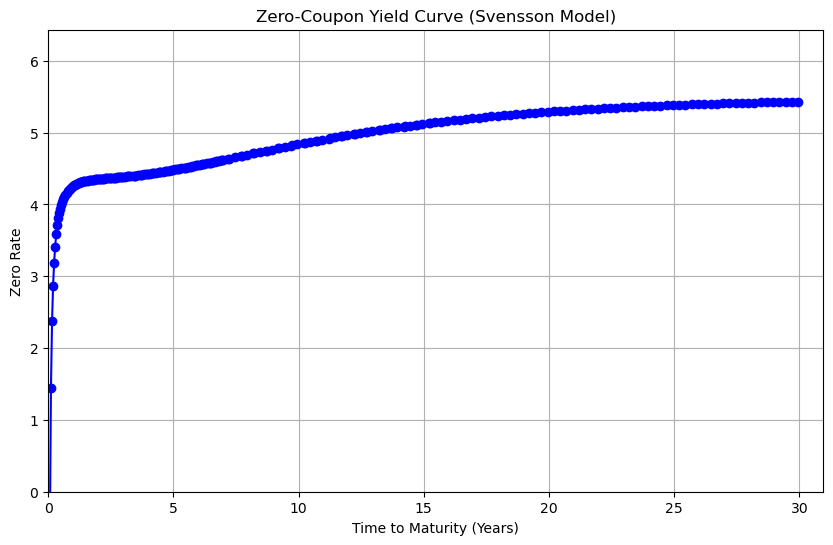

In [47]:
import matplotlib.pyplot as plt
from src.bond_funs import svensson_zero_rate
zero_rates = svensson_zero_rate(times_array, theta_optimal)
plt.figure(figsize=(10, 6))
plt.plot(times_array, zero_rates*100, marker='o', linestyle='-', color='b')
plt.title('Zero-Coupon Yield Curve (Svensson Model)')
plt.xlim(0, max(times_array) + 1)
plt.ylim(0, max(zero_rates*100) + 1)
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Zero Rate')
plt.grid(True)
plt.show()


Next we will plot the yields and cmpare it to the actual yields 

(2.937, 6.365889768961891)

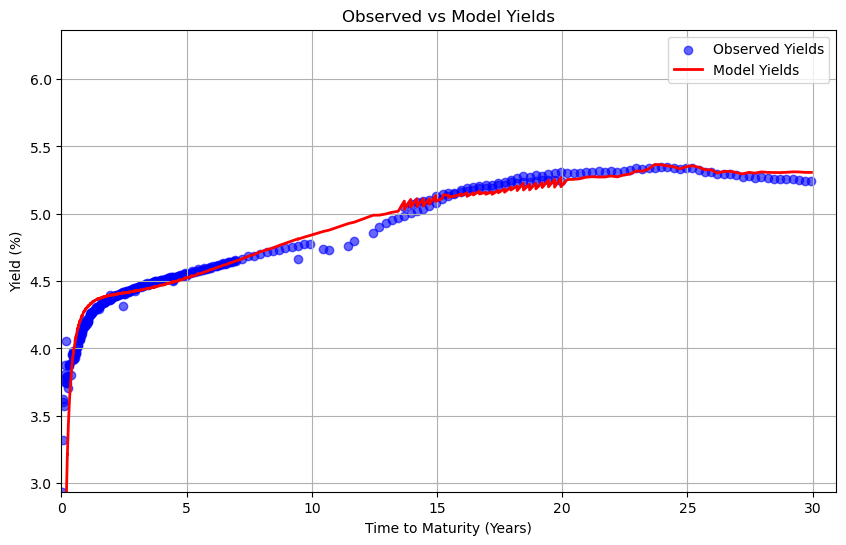

In [38]:
from src.bond_funs import model_dirty_price, ytm_from_price
model_prices = [model_dirty_price(b['times'], b['cash_flows'], theta_optimal) for b in bonds_data]
model_ytm = [ytm_from_price(price, b['times'], b['cash_flows']) for price, b in zip(model_prices, bonds_data)]
plt.figure(figsize=(10, 6))
plt.scatter(bond_data['DTM']/365.25, bond_data['Asked yield'], color='blue', label='Observed Yields', alpha=0.6)
plt.plot(bond_data['DTM']/365.25, np.array(model_ytm)*100, color='red', label='Model Yields', linewidth=2)
plt.title('Observed vs Model Yields')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Yield (%)')
plt.legend()
plt.grid(True)
plt.xlim(0, max(bond_data['DTM']/365.25) + 1)
plt.ylim(bond_data['Asked yield'].min(), max(bond_data['Asked yield'].max(), np.array(model_ytm).max()*100) + 1)




(45.774966032608695, 108.96864864468581)

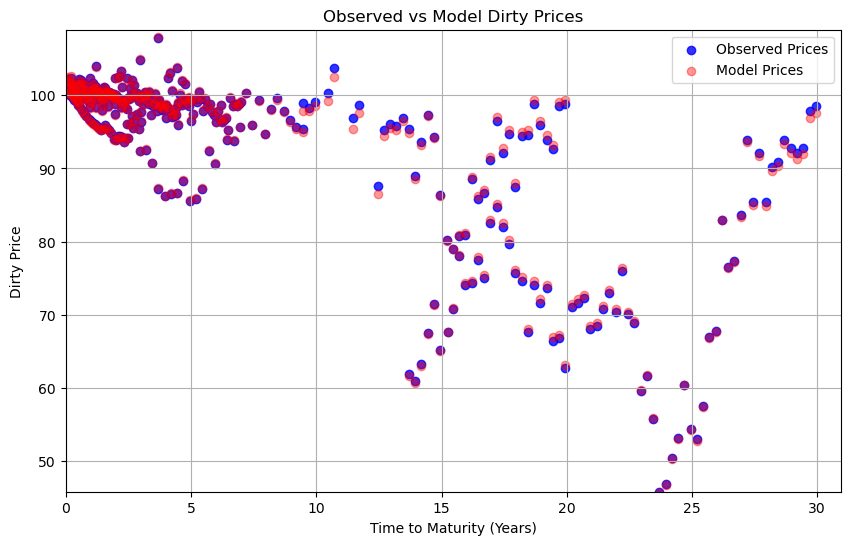

In [55]:
# plot prices
plt.figure(figsize=(10, 6))
plt.scatter(bond_data['DTM']/365.25, bond_data['Dirty Price'],
                color='blue', label='Observed Prices', alpha=0.8)
plt.scatter(bond_data['DTM']/365.25, model_prices, color='red', label='Model Prices', alpha=0.4)
plt.title('Observed vs Model Dirty Prices')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Dirty Price')
plt.legend()
plt.grid(True)
plt.xlim(0, max(bond_data['DTM']/365.25) + 1)
plt.ylim(bond_data['Dirty Price'].min(), max(bond_data['Dirty Price'].max(), max(model_prices)) + 1)


(0.19654752117076857, 1.1023026776671887)

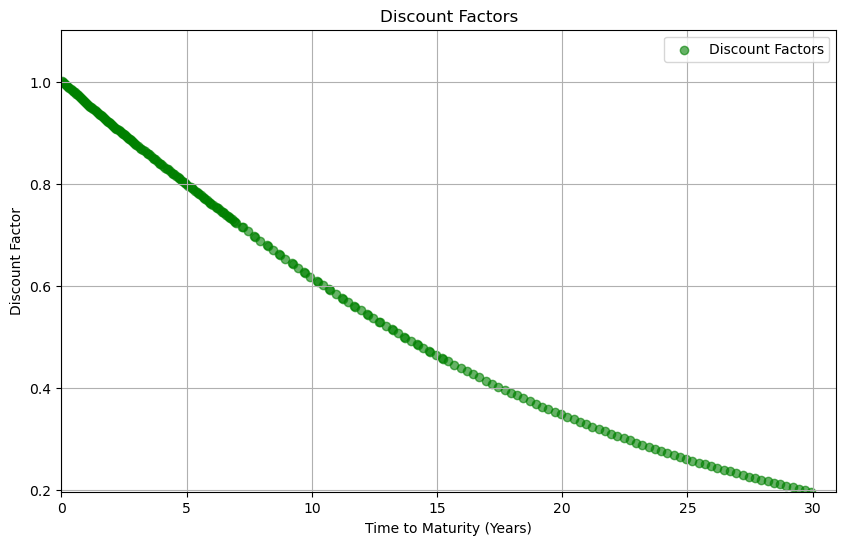

In [53]:
# discount factors plot
plt.figure(figsize=(10, 6))
discount_factors = np.exp(-zero_rates * times_array)
plt.scatter(times_array, discount_factors, color='green', label='Discount Factors', alpha=0.6)  
plt.title('Discount Factors')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Discount Factor')
plt.legend()
plt.grid(True)
plt.xlim(0, max(times_array) + 1)
plt.ylim(discount_factors.min(), discount_factors.max() + .1)


## Analysis 

As we can see, the yields and prices are very similiar of those of the actual market. And the discount factores are decreasing, also the zero rates are increasing in a decreasing trend.

